# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

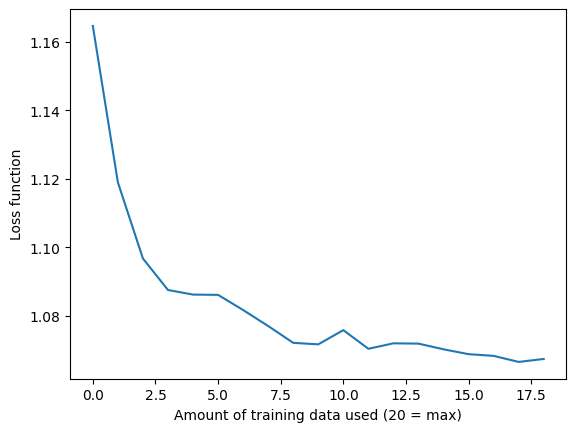

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

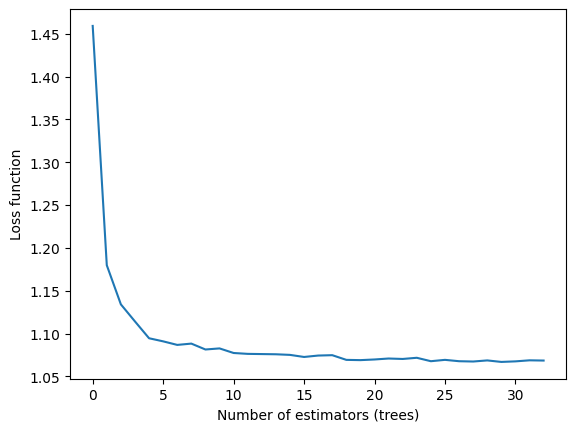

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your own datasets that you found last semester.

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

Implement a random forest model

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [9]:

# Load the dataset
df = pd.read_csv('Heart_disease_statlog.csv')

# Check for missing values
print(df.isnull().sum())

# Show the first few rows of the dataset
print(df.head())

# If needed, encode categorical variables (for example 'sex' and 'cp' could be categorical)
df['sex'] = df['sex'].astype('category')
df['cp'] = df['cp'].astype('category')
df['fbs'] = df['fbs'].astype('category')
df['restecg'] = df['restecg'].astype('category')
df['slope'] = df['slope'].astype('category')
df['ca'] = df['ca'].astype('category')
df['thal'] = df['thal'].astype('category')

# Split data into features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   70    1   3       130   322    0        2      109      0      2.4      1   
1   67    0   2       115   564    0        2      160      0      1.6      1   
2   57    1   1       124   261    0        0      141      0      0.3      0   
3   64    1   3       128   263    0        0      105      1      0.2      1   
4   74    0   1       120   269    0        2      121      1      0.2      0   

   ca  thal  target  
0   3     1       1  
1   0     3       0  
2   0     3       1  
3   1     3       0  
4   1     1       0  


In [13]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Fit the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7654320987654321
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82        49
           1       0.76      0.59      0.67        32

    accuracy                           0.77        81
   macro avg       0.76      0.74      0.74        81
weighted avg       0.76      0.77      0.76        81



The model has an accuracy of 76.5%. This means that the Random Forest model correctly predicted whether a person had heart disease or not 76.5% of the time on the test data.

Precision: Precision is the proportion of positive predictions that are actually correct.
For class 0 (no heart disease), the precision is 0.77, meaning 77% of the time when the model predicts no heart disease, it’s correct.
For class 1 (heart disease), the precision is 0.76, meaning 76% of the time when the model predicts heart disease, it’s correct.

Recall: Recall (also known as sensitivity) is the proportion of actual positives that are correctly identified by the model.
For class 0 (no heart disease), the recall is 0.88, meaning the model correctly identifies 88% of all actual no-heart-disease cases.
For class 1 (heart disease), the recall is 0.59, meaning the model identifies 59% of all actual heart disease cases. This is relatively lower, suggesting the model is better at identifying no heart disease than heart disease.

F1-score: The F1-score is the harmonic mean of precision and recall. It gives a balanced measure of performance for both classes.
For class 0 (no disease), the F1-score is 0.82, which indicates a good balance between precision and recall for the no-heart-disease group.
For class 1 (heart disease), the F1-score is 0.67, which is lower than class 0, indicating that the model struggles a bit more in correctly predicting heart disease cases.

Macro Avg: The macro average is the average performance across all classes without considering class imbalance.
The macro average F1-score is 0.74, which suggests that overall, the model performs reasonably well but has room for improvement.

Weighted Avg: The weighted average F1-score takes class imbalance into account (i.e., the fact that there are 49 instances of class 0 and 32 of class 1).
The weighted average F1-score is 0.76, showing a good overall model performance.


Summary 

The Random Forest model has decent accuracy and performs better in identifying individuals without heart disease (class 0) compared to those with heart disease (class 1). This suggests that the model might be biased towards predicting the more prevalent class, which is something that could be further addressed with techniques like class balancing (e.g., using weighted classes or SMOTE).
We used classification instead of regression because the target variable is categorical (binary outcome: 0 or 1), and classification models, like Random Forest Classifier, are better suited for this kind of task.


Cross-Validation

In [14]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(rf, X, y, cv=5)  # 5-fold cross-validation

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", np.mean(cv_scores))


Cross-validation scores: [0.72222222 0.81481481 0.87037037 0.77777778 0.88888889]
Mean cross-validation score: 0.8148148148148149


Cross-validation scores:
The cross-validation scores for each fold are as follows:
0.72 (for the first fold)
0.81 (for the second fold)
0.87 (for the third fold)
0.78 (for the fourth fold)
0.89 (for the fifth fold)
These scores represent the model's accuracy on different subsets of the data during cross-validation. The model's performance varies slightly across the folds, with the lowest score being 0.72 and the highest being 0.89.

Mean cross-validation score:
The mean cross-validation score is 0.81, which represents the average accuracy across all 5 folds.
This suggests that the Random Forest model performs quite well on different subsets of the data, with a moderate variance in performance (from 0.72 to 0.89).

Good Model Performance: The mean cross-validation score of 0.81 indicates that the model generally performs well across all folds. It shows that the Random Forest model is stable and reliable in terms of generalization.

Variance in Performance: The slight variation in scores (from 0.72 to 0.89) could indicate that the model’s performance may be influenced by specific subsets of the data. This could be due to factors such as the distribution of data or class imbalance.

Overall Positive Indication: Since the mean score is relatively high (0.81), it suggests that the Random Forest model is effective for this classification task, though there might be room for further optimization or addressing minor performance inconsistencies (e.g., through techniques like class balancing or hyperparameter tuning).


Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)

# Fit grid search
grid_search.fit(X_train, y_train)

# Get the best parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the model with the best hyperparameters
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Print classification report
print("Classification Report (Best Model):\n", classification_report(y_test, y_pred_best))


Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END ma

The hyperparameter tuning improved the model's performance, increasing accuracy to 84%. The model now balances predictions better between heart disease (class 1) and no heart disease (class 0).

Precision and recall for both classes improved, meaning the model is now better at predicting both outcomes.
Cross-validation showed the model is consistent, with an average score of 81% across different data splits.

Overall, tuning helped the model generalize better and improved its accuracy and ability to predict both classes fairly. You can continue improving by exploring feature importance or dealing with class imbalance if needed.

Evaluate Performance Metrics

In [16]:
from sklearn.metrics import roc_auc_score, confusion_matrix

# ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_best)
print("ROC AUC Score:", roc_auc)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:\n", conf_matrix)


ROC AUC Score: 0.8077168367346937
Confusion Matrix:
 [[47  2]
 [11 21]]


The ROC AUC score of 0.81 indicates that the model performs well at distinguishing between heart disease (class 1) and no heart disease (class 0). A value close to 1 means the model is effective at distinguishing the two classes.

The confusion matrix:

- 47 true negatives (correctly predicted no heart disease)
- 2 false positives (incorrectly predicted heart disease when there wasn't)
- 11 false negatives (missed heart disease cases)
- 21 true positives (correctly predicted heart disease)

Overall, the model does a good job, with relatively few false positives and false negatives.

Visualization

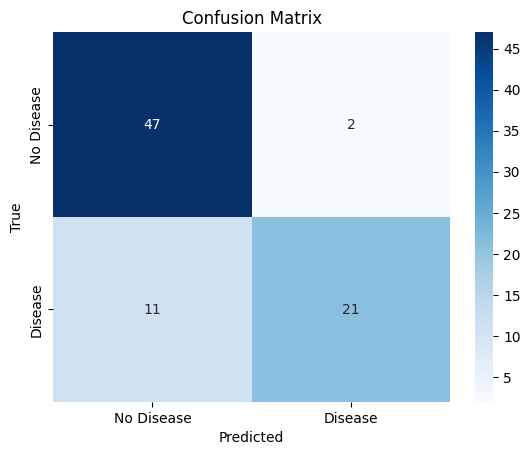

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

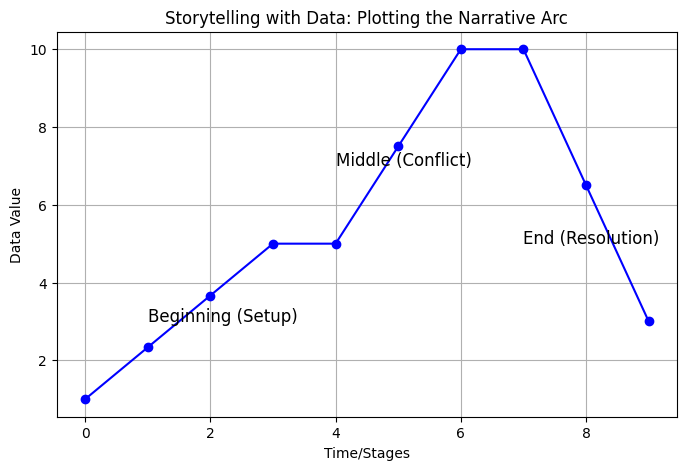

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create data for the plot: three phases: setup, conflict, and resolution
x = np.arange(0, 10)
y = np.concatenate([np.linspace(1, 5, 4), np.linspace(5, 10, 3), np.linspace(10, 3, 3)])

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', color='b')

# Add labels to describe the story structure
plt.text(1, 3, 'Beginning (Setup)', fontsize=12, color='black')
plt.text(4, 7, 'Middle (Conflict)', fontsize=12, color='black')
plt.text(7, 5, 'End (Resolution)', fontsize=12, color='black')

# Label the axes
plt.xlabel('Time/Stages')
plt.ylabel('Data Value')

# Title the plot
plt.title('Storytelling with Data: Plotting the Narrative Arc')

# Show the plot
plt.grid(True)
plt.show()


There was no graph in this chapter to replicate but here is the concept from my understanding. 

Beginning (Setup): The data increases gradually, starting from a lower value and showing the initial situation.
Middle (Conflict): There's a dramatic rise in the data, representing the "conflict" or the dramatic twist.
End (Resolution): The data starts to decline, indicating the resolution or resolution of the conflict.
This plot structure visually represents the three-act structure of storytelling using data.